# Benchmark VGG16-BN / CIFAR-10 — Comparativa AWS vs Azure

**Objetivo:** medir rendimiento de hardware (GPU T4) entrenando un modelo.
El proveedor (AWS SageMaker/AzureML) es la variable a comparar.

**Config de este experimento**
- Modelo: VGG16 con BatchNorm, adaptado a 32x32 (aprende de verdad, ~85-90% acc esperado)
- Datos: Kaggle `fedesoriano/cifar10-python-in-csv` (cuenta compartida de clase), 32x32 nativo
- Optimizer: SGD momentum + CosineAnnealing | 30 epochs | batch 128
- Metricas: WandB (GPU/CPU/RAM del sistema) + log nvidia-smi (util, VRAM, energia, temp) + costo

**Para replicar en Azure:** usar ESTE MISMO notebook, mismo `SEED=42`,
misma funcion de carga, mismos hiperparametros. Solo cambian los campos `cloud`/`instance`/`region`
en la config de WandB, y el precio/hora para el costo.


In [1]:
# torch ya viene en el kernel conda_pytorch_p310
!pip install kagglehub wandb --quiet

In [2]:
!nvidia-smi
import torch
print("CUDA:", torch.cuda.is_available(), "| GPU:", torch.cuda.get_device_name(0))

Sat Jul 18 16:11:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   44C    P0             33W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np, pandas as pd, os, time, random
from sklearn.model_selection import train_test_split

In [4]:
# Reproducibilidad
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Dispositivo:", device)

Dispositivo: cuda


In [5]:
# Descarga del dataset desde Kaggle (credencial configurada en la TERMINAL, no aqui).
import kagglehub
path = kagglehub.dataset_download("fedesoriano/cifar10-python-in-csv")
print("Dataset (disco gp3):", path)
print(os.listdir(path))

Dataset (disco gp3): /home/ec2-user/.cache/kagglehub/datasets/fedesoriano/cifar10-python-in-csv/versions/1
['batches.meta', 'test.csv', 'train.csv']


In [6]:
# Carga CIFAR-10 desde CSV de Kaggle.
# Puntos clave descubiertos: la etiqueta esta en la ULTIMA columna ('label'),
# los 3072 pixeles vienen en layout CHW-plano (R*1024, G*1024, B*1024).
# test.csv NO trae etiquetas -> se parte train.csv 80/20 estratificado.
# Se entrena a 32x32 NATIVO (sin upscale): mas rapido, menos RAM, mejor accuracy.
# El companero de Azure debe usar ESTA MISMA funcion.

# Normalizacion con la media/std reales de CIFAR-10 (mejor que ImageNet para este dataset)
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

def _find_csv(path, keyword):
    for f in os.listdir(path):
        if f.lower().endswith('.csv') and keyword in f.lower():
            return os.path.join(path, f)
    raise FileNotFoundError(f"No hay CSV '{keyword}' en {path}")

class CIFAR10CSV(Dataset):
    def __init__(self, images_chw, labels, train=False):
        # images_chw: (N,3,32,32) float32 en [0,1]
        self.images = images_chw
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.train = train

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.images[idx])          # (3,32,32)
        if self.train:
            # Data augmentation ligero (mismo en ambas nubes -> deterministico por seed global)
            if random.random() < 0.5:
                x = torch.flip(x, dims=[2])             # flip horizontal
            # padding + random crop
            xp = torch.nn.functional.pad(x.unsqueeze(0), (4,4,4,4), mode='reflect').squeeze(0)
            top = random.randint(0, 8); left = random.randint(0, 8)
            x = xp[:, top:top+32, left:left+32]
        x = (x - MEAN) / STD
        return x, self.labels[idx]

def load_cifar10_dataset(batch_size=128, root=None, val_split=0.2, seed=42):
    df = pd.read_csv(_find_csv(root, 'train'))
    labels = df['label'].values
    pixels = df.drop(columns=['label']).values.astype(np.float32) / 255.0
    images = pixels.reshape(-1, 3, 32, 32)             # CHW plano
    X_tr, X_val, y_tr, y_val = train_test_split(
        images, labels, test_size=val_split, random_state=seed, stratify=labels)
    train_ds = CIFAR10CSV(X_tr, y_tr, train=True)
    val_ds   = CIFAR10CSV(X_val, y_val, train=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    print(f"train: {len(train_ds)} | val: {len(val_ds)}")
    return train_loader, val_loader

train: 40000 | val: 10000


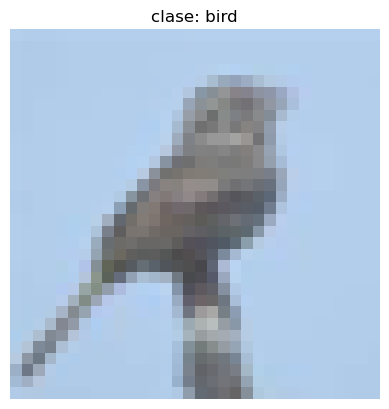

In [7]:
# Verificacion visual (debe verse un objeto reconocible)
import matplotlib.pyplot as plt
train_loader, test_loader = load_cifar10_dataset(batch_size=128, root=path)
xb, yb = next(iter(test_loader))   # usar val (sin augmentation) para ver limpio
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
img = (xb[0] * STD + MEAN).permute(1,2,0).numpy()
plt.imshow(np.clip(img,0,1)); plt.title(f"clase: {classes[yb[0]]}"); plt.axis('off'); plt.show()

In [8]:
# VGG16 con BatchNorm, adaptado a entrada 32x32.
# Misma estructura convolucional de VGG16; BatchNorm estabiliza el entrenamiento
# (sin el, con lr alto, el modelo colapsaba a predecir una sola clase = 10% acc).

cfg_vgg16 = [64,64,'M',128,128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M']

class VGG16BN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        layers = []
        in_ch = 3
        for v in cfg_vgg16:
            if v == 'M':
                layers += [nn.MaxPool2d(2, 2)]
            else:
                layers += [nn.Conv2d(in_ch, v, kernel_size=3, padding=1),
                           nn.BatchNorm2d(v),
                           nn.ReLU(inplace=True)]
                in_ch = v
        self.features = nn.Sequential(*layers)
        # con 5 poolings sobre 32x32 -> 1x1 espacial, 512 canales
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [9]:
model = VGG16BN(num_classes=10).to(device)

num_epochs = 30
batch_size = 128
learning_rate = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9,
                      weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parametros: {n_params:,}")

Parametros: 14,990,922


### Metricas (WandB)
Ejecuta, elige opcion **2** (cuenta existente) y pega tu API key.
Acuerda con tu companero el MISMO `project`; cambia solo `cloud`/`instance`/`region`.

In [10]:
import wandb
wandb.login()  # opcion 2 -> pega tu API key

run = wandb.init(
    project="benchmark-cloud-vgg16",
    name="aws-sagemaker-g4dn-xlarge",
    config={
        "cloud":"AWS", "instance":"ml.g4dn.xlarge", "gpu":"NVIDIA T4 16GB",
        "vcpu":4, "ram_gb":16, "storage":"gp3-100GB", "region":"us-east-2",
        "price_per_hour_usd":0.7364,          # g4dn.xlarge SageMaker on-demand us-east-2
        "dataset_source":"kaggle:fedesoriano/cifar10-python-in-csv",
        "model":"VGG16-BN", "input_size":32, "num_classes":10,
        "batch_size":batch_size, "optimizer":"SGD-momentum-nesterov",
        "lr":learning_rate, "weight_decay":5e-4, "scheduler":"CosineAnnealing",
        "epochs":num_epochs, "seed":SEED
    }
)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ec2-user/.netrc.
wandb: Currently logged in as: rendimientocostosmlaas (rendimientocostosmlaas-universidad-nacional-de-loja) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
# Log de hardware en paralelo -> gpu_log.csv
# Captura: utilizacion GPU y memoria, VRAM usada, temperatura, POTENCIA (watts) = energia
import subprocess
gpu_proc = subprocess.Popen(
    "nvidia-smi --query-gpu=timestamp,utilization.gpu,utilization.memory,"
    "memory.used,temperature.gpu,power.draw --format=csv -l 2 > gpu_log.csv 2>&1 &",
    shell=True)
print("Log de GPU -> gpu_log.csv (cada 2s)")

Log de GPU -> gpu_log.csv (cada 2s)


In [12]:
# ===== ENTRENAMIENTO CON MEDICION DE RENDIMIENTO =====
n_train = len(train_loader.dataset)
t_total = time.time()
best_acc = 0.0

for epoch in range(num_epochs):
    t0 = time.time()
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / n_train

    # Validacion
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    avg_val_loss = val_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total
    scheduler.step()

    epoch_time = time.time() - t0
    throughput = n_train / epoch_time          # imagenes/segundo (metrica clave de rendimiento)
    best_acc = max(best_acc, accuracy)

    wandb.log({
        "epoch": epoch+1,
        "train_loss": epoch_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": accuracy,
        "best_accuracy": best_acc,
        "epoch_time_s": epoch_time,
        "throughput_img_per_s": throughput,
        "gpu_mem_peak_GB": torch.cuda.max_memory_allocated()/1e9,
        "lr": optimizer.param_groups[0]["lr"],
    })
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"loss {epoch_loss:.3f} | val_loss {avg_val_loss:.3f} | "
          f"acc {accuracy:5.2f}% | {epoch_time:5.1f}s | {throughput:6.0f} img/s")

total_time = time.time() - t_total
avg_epoch = total_time / num_epochs
cost = (total_time/3600) * run.config["price_per_hour_usd"]

wandb.log({
    "total_train_time_s": total_time,
    "avg_epoch_time_s": avg_epoch,
    "final_accuracy": accuracy,
    "estimated_cost_usd": cost,
})
print("="*60)
print(f"TIEMPO TOTAL: {total_time:.1f}s ({total_time/60:.2f} min)")
print(f"TIEMPO/EPOCA (prom): {avg_epoch:.1f}s")
print(f"ACCURACY FINAL: {accuracy:.2f}% | MEJOR: {best_acc:.2f}%")
print(f"COSTO ESTIMADO AWS: ${cost:.4f} USD")
print("="*60)

Epoch [ 1/30] loss 2.125 | val_loss 1.917 | acc 19.33% |  17.5s |   2286 img/s
Epoch [ 2/30] loss 1.950 | val_loss 1.886 | acc 23.75% |  17.2s |   2327 img/s
Epoch [ 3/30] loss 1.820 | val_loss 1.627 | acc 36.04% |  17.3s |   2312 img/s
Epoch [ 4/30] loss 1.600 | val_loss 1.466 | acc 41.34% |  17.3s |   2310 img/s
Epoch [ 5/30] loss 1.399 | val_loss 1.265 | acc 52.57% |  17.4s |   2301 img/s
Epoch [ 6/30] loss 1.182 | val_loss 1.120 | acc 60.87% |  17.4s |   2304 img/s
Epoch [ 7/30] loss 0.984 | val_loss 1.455 | acc 55.92% |  17.4s |   2299 img/s
Epoch [ 8/30] loss 0.886 | val_loss 0.822 | acc 71.70% |  17.4s |   2297 img/s
Epoch [ 9/30] loss 0.797 | val_loss 0.846 | acc 72.44% |  17.4s |   2297 img/s
Epoch [10/30] loss 0.733 | val_loss 1.237 | acc 66.85% |  17.5s |   2291 img/s
Epoch [11/30] loss 0.681 | val_loss 0.828 | acc 73.80% |  17.5s |   2288 img/s
Epoch [12/30] loss 0.636 | val_loss 0.696 | acc 78.19% |  17.5s |   2291 img/s
Epoch [13/30] loss 0.588 | val_loss 0.632 | acc 79.7

In [13]:
# Detener el log de GPU
gpu_proc.terminate()
subprocess.run("pkill -f 'nvidia-smi --query-gpu' || true", shell=True)

# Resumen del log de hardware (util media, VRAM pico, energia media, temp media)
try:
    gl = pd.read_csv('gpu_log.csv')
    gl.columns = [c.strip() for c in gl.columns]
    def num(col):
        return pd.to_numeric(gl[col].astype(str).str.replace(r'[^0-9.]','',regex=True), errors='coerce')
    util  = num('utilization.gpu [%]')
    vram  = num('memory.used [MiB]')
    power = num('power.draw [W]')
    temp  = num('temperature.gpu')
    resumen = {
        "gpu_util_media_%": round(util.mean(),1),
        "gpu_util_max_%": round(util.max(),1),
        "vram_media_MiB": round(vram.mean(),0),
        "vram_pico_MiB": round(vram.max(),0),
        "potencia_media_W": round(power.mean(),1),
        "potencia_pico_W": round(power.max(),1),
        "temp_media_C": round(temp.mean(),1),
        "temp_max_C": round(temp.max(),1),
    }
    print("Resumen de hardware (nvidia-smi):")
    for k,v in resumen.items():
        print(f"  {k}: {v}")
    wandb.log({f"hw_{k}":v for k,v in resumen.items()})
except Exception as e:
    print("No se pudo resumir gpu_log.csv:", e)

wandb.finish()

Resumen de hardware (nvidia-smi):
  gpu_util_media_%: 97.5
  gpu_util_max_%: 100
  vram_media_MiB: 912.0
  vram_pico_MiB: 915
  potencia_media_W: 68.0
  potencia_pico_W: 73.2
  temp_media_C: 55.8
  temp_max_C: 57


avg_epoch_time_s,▁
best_accuracy,▁▁▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇███████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_time_s,█▁▃▄▅▅▆▆▆▇█▇▇▇▇▇▇███▇▇▇▇▇▇▇▇▇▇
estimated_cost_usd,▁
final_accuracy,▁
gpu_mem_peak_GB,▁█████████████████████████████
hw_gpu_util_max_%,▁
hw_gpu_util_media_%,▁
hw_potencia_media_W,▁
+11,...


### Matriz de confusion y reporte

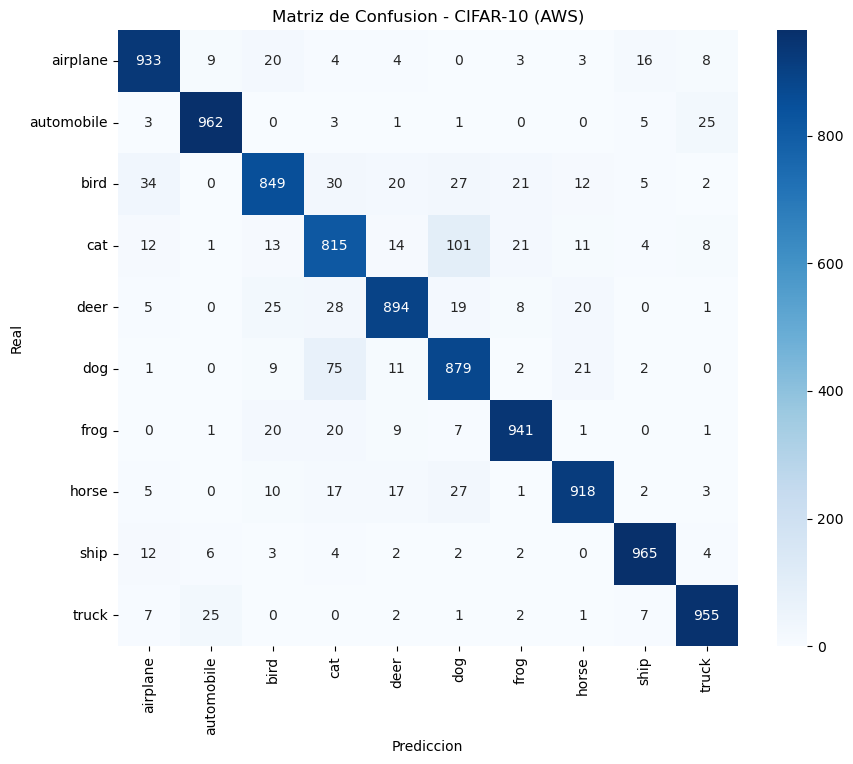

              precision    recall  f1-score   support

    airplane       0.92      0.93      0.93      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.89      0.85      0.87      1000
         cat       0.82      0.81      0.82      1000
        deer       0.92      0.89      0.91      1000
         dog       0.83      0.88      0.85      1000
        frog       0.94      0.94      0.94      1000
       horse       0.93      0.92      0.92      1000
        ship       0.96      0.96      0.96      1000
       truck       0.95      0.95      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, preds = torch.max(model(images), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Prediccion'); plt.ylabel('Real'); plt.title('Matriz de Confusion - CIFAR-10 (AWS)')
plt.savefig('matriz_confusion_aws.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

In [15]:
# Guardar modelo entrenado (anexo para el informe)
torch.save(model.state_dict(), 'modelo_vgg16_aws.pth')
print("Modelo guardado: modelo_vgg16_aws.pth")

Modelo guardado: modelo_vgg16_aws.pth


### Al terminar
1. Descarga: `gpu_log.csv`, `matriz_confusion_aws.png`, `modelo_vgg16_aws.pth`.
2. Metricas completas en tu dashboard de WandB.
3. CloudWatch: SageMaker -> tu notebook instance -> monitoreo -> Ver metricas de instancia (captura CPU/RAM/disco).
4. **APAGA la instancia**: SageMaker -> Notebooks -> Stop.

**Para Azure:** mismo notebook. Cambia en la config de WandB: `cloud`, `instance`,
`region`, `price_per_hour_usd`. Todo lo demas identico.
